# Experiment No. 03: Binary Phase Shift Keying

## Title

**Implementation of Binary Phase Shift Keying (BPSK) using Python**

## Aim

To generate and demodulate a Binary Phase Shift Keying (BPSK) signal using Python.

## Experimental Requirements

- Python 3
- Jupyter Notebook or Google Colab
- NumPy
- Matplotlib

## Theory

Binary Phase Shift Keying (BPSK) is a digital modulation technique in which the **phase of a carrier signal is changed according to the binary input data**.

The binary data is first converted into polar form:

$$
1 \rightarrow +1
$$

$$
0 \rightarrow -1
$$

If the carrier signal is

$$
c(t)=\cos(2\pi f_c t)
$$

then the BPSK signal is

$$
s(t)=m(t)c(t)
$$

where $m(t)$ is the polar binary signal.

Therefore,

$$
s(t)=
\begin{cases}
\cos(2\pi f_c t), & \text{for bit 1}\\
-\cos(2\pi f_c t), & \text{for bit 0}
\end{cases}
$$

Thus, binary `1` and `0` are represented by two carrier phases differing by

$$
180^\circ
$$

At the receiver, the BPSK signal is multiplied by a synchronized carrier and integrated over each bit interval. A positive result is detected as bit `1`, while a negative result is detected as bit `0`.

## BPSK System Flow

**Binary Data → Polar Encoding → Product Modulator → BPSK Signal**

At the receiver:

**BPSK Signal → Coherent Detector → Decision Device → Recovered Data**

## Algorithm

1. Define the binary information sequence.
2. Convert the binary data into polar form.
3. Generate the carrier signal.
4. Multiply the polar data with the carrier to generate BPSK.
5. Demodulate using the same synchronized carrier.
6. Apply a threshold to recover the binary data.
7. Calculate BER and plot the important waveforms.

## Output

The program displays:

1. Original binary data
2. Polar message signal
3. Carrier signal
4. BPSK signal
5. Recovered binary data
6. Bit Error Rate

## Result and Discussion

The binary data was successfully converted into polar form and modulated using BPSK. The carrier phase changed by $180^\circ$ according to the binary input.

At the receiver, coherent detection and threshold decision successfully recovered the original binary sequence. For the ideal noiseless channel, the Bit Error Rate was zero.

## Conclusion

Binary Phase Shift Keying was successfully implemented using Python. The experiment demonstrated polar encoding, phase modulation, coherent demodulation, and recovery of the original binary data.

Original Data  : [1 0 0 1 1 1 0]
Polar Data     : [ 1 -1 -1  1  1  1 -1]
Recovered Data : [1 0 0 1 1 1 0]
Bit Errors     : 0
Bit Error Rate : 0.0


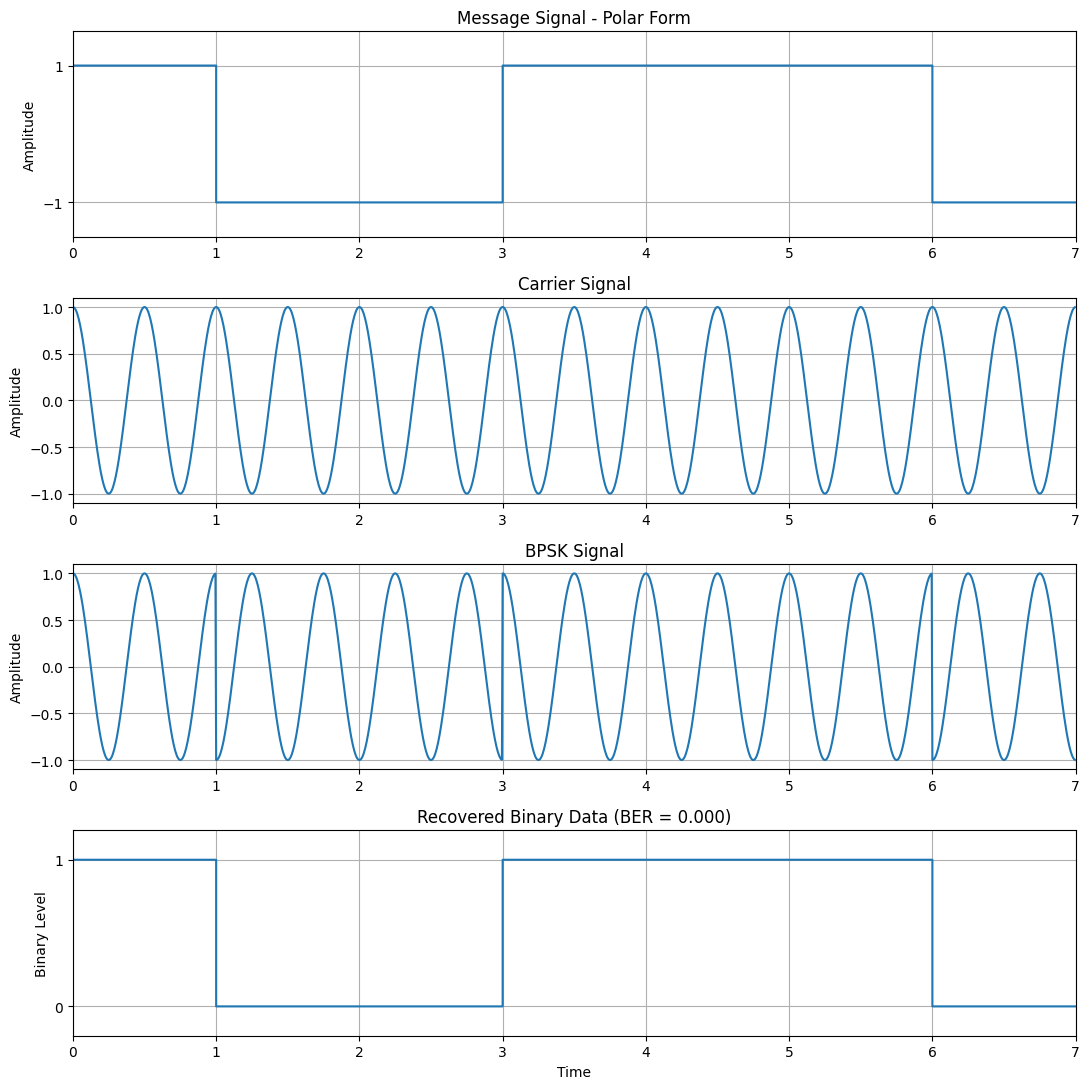

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# BPSK PARAMETERS
# ============================================================

# Binary sequence from the laboratory experiment
data = np.array([1, 0, 0, 1, 1, 1, 0])

samples_per_bit = 200
carrier_frequency = 2


# ============================================================
# POLAR CONVERSION
# ============================================================

# Binary:
# 1 -> +1
# 0 -> -1

polar_data = 2 * data - 1

message_signal = np.repeat(
    polar_data,
    samples_per_bit
)


# ============================================================
# TIME AXIS AND CARRIER
# ============================================================

time = np.arange(
    len(message_signal)
) / samples_per_bit

carrier = np.cos(
    2 * np.pi *
    carrier_frequency *
    time
)


# ============================================================
# BPSK MODULATION
# ============================================================

bpsk_signal = (
    message_signal * carrier
)


# ============================================================
# BPSK DEMODULATION
# ============================================================

demodulated = (
    bpsk_signal * carrier
)

recovered_data = []

for i in range(len(data)):

    start = i * samples_per_bit
    stop = start + samples_per_bit

    # Integrate over one bit interval
    value = np.sum(
        demodulated[start:stop]
    )

    if value >= 0:
        recovered_data.append(1)
    else:
        recovered_data.append(0)

recovered_data = np.array(
    recovered_data
)


# ============================================================
# BIT ERROR RATE
# ============================================================

bit_errors = np.count_nonzero(
    data != recovered_data
)

ber = bit_errors / len(data)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("Original Data  :", data)
print("Polar Data     :", polar_data)
print("Recovered Data :", recovered_data)
print("Bit Errors     :", bit_errors)
print("Bit Error Rate :", ber)


# ============================================================
# PLOTTING
# ============================================================

plt.figure(figsize=(11, 11))


# 1. Polar message signal
plt.subplot(4, 1, 1)

plt.step(
    time,
    message_signal,
    where="post"
)

plt.title("Message Signal - Polar Form")
plt.ylabel("Amplitude")
plt.yticks([-1, 1])
plt.ylim(-1.5, 1.5)
plt.xlim(0, len(data))
plt.grid()


# 2. Carrier signal
plt.subplot(4, 1, 2)

plt.plot(
    time,
    carrier
)

plt.title("Carrier Signal")
plt.ylabel("Amplitude")
plt.xlim(0, len(data))
plt.grid()


# 3. BPSK signal
plt.subplot(4, 1, 3)

plt.plot(
    time,
    bpsk_signal
)

plt.title("BPSK Signal")
plt.ylabel("Amplitude")
plt.xlim(0, len(data))
plt.grid()


# 4. Recovered data
recovered_waveform = np.repeat(
    recovered_data,
    samples_per_bit
)

plt.subplot(4, 1, 4)

plt.step(
    time,
    recovered_waveform,
    where="post"
)

plt.title(
    f"Recovered Binary Data (BER = {ber:.3f})"
)

plt.xlabel("Time")
plt.ylabel("Binary Level")
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.xlim(0, len(data))
plt.grid()


plt.tight_layout()
plt.show()